## Working File to Test and Run Code Segments

# Function to change image resolution to desired size


Sharpening: (455, 455) vs [256, 256]
Sharpening: (361, 361) vs [256, 256]
(228, 228, 3)


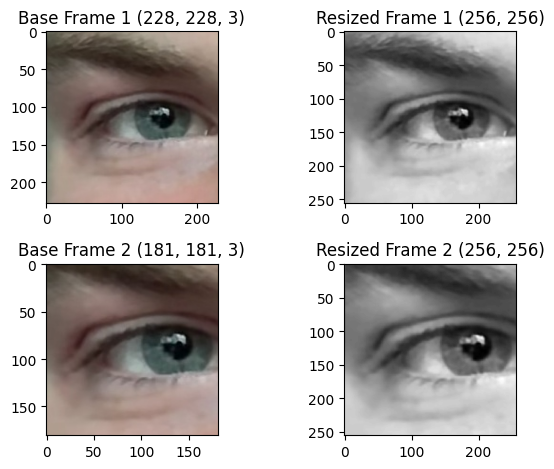

In [1]:
import numpy 
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
import os

def blur_and_sample(img, a=0.4):
    # Enter your code here
    
    # build Gaussian Mask
    gaussMask = numpy.array([[.25-.5*a, .25, a, .25, .25-.5*a]])
    gaussMask = gaussMask / gaussMask.sum()
    #print(gaussMask, gaussMask.shape) # debugging
    #print(img.shape)

    # correlate row-wise
    rowBlurred = ndimage.correlate(img, gaussMask)
    blurred = ndimage.correlate(rowBlurred, gaussMask.T)

    # initialize new photo
    nRows = int(numpy.ceil(img.shape[0] / 2))
    nCols = int(numpy.ceil(img.shape[1] / 2))
    downsampled_img = numpy.zeros([nRows, nCols])

    # sample pixels for the downsampled image
    for row in range(0, nRows):
        for col in range(0, nCols):
            bRow = row*2
            bCol = col*2
            downsampled_img[row, col] = numpy.mean(blurred[bRow:bRow+1, bCol:bCol+1])
    
    return downsampled_img

def sharpen(img):
    # Enter your code here
    
    # initialize new photo
    nRows = int(img.shape[0] * 2 - 1)
    nCols = int(img.shape[1] * 2 - 1)
    upsampled_img = numpy.zeros([nRows, nCols])
    
    # assign odd (even index) row,col values to correspond to known values
    for row in range(0, nRows, 2):
        for col in range(0, nCols, 2):
            upsampled_img[row, col] = img[int(row/2)-1, int(col/2)-1]

    # assign even (odd index) row,col values using interpolation
    for row in range(1, nRows, 2):
        for col in range(1, nCols, 2):
            inputRow = int((row - 1) / 2)
            inputCol = int((col - 1)/ 2)
            upsampled_img[row, col] = numpy.mean(img[inputRow:inputRow+1, inputCol:inputCol+1])

    return upsampled_img

def downsample_to_ideal(image, ideal_shape = [256,256], a=0.4):
# Function that an image as an input and updates the resolution of each image to make the ideal shape. 
# Uses downsampling to decrease resolution
# Inputs:
#   image: A square image that is larger or equal to the ideal_shape image, but not more than twice the size
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
# Outputs:  
#   resized_image: The image resized to the ideal_shape


    # initialize new photo
    resized_image = numpy.zeros(ideal_shape)

    # scaling factor
    scale_factor = ideal_shape[0] / image.shape[0]
    # print(scale_factor)

    # build Gaussian Mask
    gaussMask = numpy.array([[.25-.5*a, .25, a, .25, .25-.5*a]])
    gaussMask = gaussMask / gaussMask.sum()
    #print(gaussMask, gaussMask.shape) # debugging
    #print(img.shape)

    # correlate row-wise
    rowBlurred = ndimage.correlate(image, gaussMask)
    blurred = ndimage.correlate(rowBlurred, gaussMask.T)

    # downsample to fill the photo
    for row in range(0, ideal_shape[0]):
        for col in range(0, ideal_shape[1]):

            # translate row and col number to original image
            original_row = row / scale_factor
            original_row_rounded = int(round(original_row, 0))
            original_row_rerror = original_row - original_row_rounded

            original_col = col / scale_factor
            original_col_rounded = int(round(original_col, 0))
            original_col_rerror = original_col - original_col_rounded

            # take gaussian average based on distance from actual value: 
            resized_image[row, col] = blurred[original_row_rounded, original_col_rounded]

    return resized_image



def change_resolution(image, ideal_shape = [256,256], testing=False, saving=False):
# Function that takes an array of images as an input and updates the resolution of each image to make the ideal shape. 
# Uses blurring or reverse blurring/sharpening to decrease and increase resolution (respectively)
# Inputs:
#   images: An array of images
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
# Outputs:  
#   resized_images: The image array where each image has been resized to the ideal_shape

    # first, reduce to grayscale
    image = numpy.array(image).astype('uint8')
    resized_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # while loop to determine if image is correct size
    flag = True
    while(flag):
        if resized_image.shape[0] > ideal_shape[0] * 2: # if image is too large, blur and downsample
            if testing:
                print(f'Blurring: {resized_image.shape} vs {ideal_shape}')
            resized_image = blur_and_sample(resized_image)
        elif resized_image.shape[0] < ideal_shape[0]: # if image is too small, sharpen/interpolated it
            resized_image = sharpen(resized_image)
            if testing:
                print(f'Sharpening: {resized_image.shape} vs {ideal_shape}')
        else:
            resized_image = downsample_to_ideal(resized_image, ideal_shape)
            flag = False

    return resized_image

def change_resolution_frames(images, ideal_shape = [256,256], eye_type="left", testing=False, saving=False):
# Function that takes an array of images as an input and updates the resolution of each image to make the ideal shape. 
# Uses blurring or reverse blurring/sharpening to decrease and increase resolution (respectively)
# Inputs:
#   images: A LIST of images
#   ideal_shape: The desired dimensions of each image. Has a default value to match the ML model expected input
#   testing: prints helpful debugging outputs if true
#   eye_type: "left" or "right" - impacts file name if saving
#   saving: saves each image if true
# Outputs:  
#   resized_images: The image array where each image has been resized to the ideal_shape

    # create array to hold new images
    # save frame dimensions, use to initialize an array to store the frames
    frame_dim = list(ideal_shape)
    frame_dim.insert(0, len(images))
    resized_images = numpy.zeros(frame_dim).astype('uint8')

    # Create output directory if it doesn't exist
    output_dir = './cropped_eyes/'
    os.makedirs(output_dir, exist_ok=True)

    for frame in range(0, len(images)):
        this_frame = change_resolution(images[frame], ideal_shape, testing, saving)
        resized_images[frame,:,:] = this_frame

        if saving:
            output_path = os.path.join(output_dir, f"frame_{frame:04d}_{eye_type}_eye.jpg")
            cv2.imwrite(output_path, this_frame)
    
    return(resized_images)

image = cv2.imread('./frame_0000_left_eye.jpg')
image2 = cv2.imread('./frame_0005_left_eye.jpg')

images = list()
images.append(image)
images.append(image2)

corrected_image = numpy.zeros_like(image)
corrected_image[:,:,0] = image[:,:,2]
corrected_image[:,:,1] = image[:,:,1]
corrected_image[:,:,2] = image[:,:,0]

corrected_image2 = numpy.zeros_like(image2)
corrected_image2[:,:,0] = image2[:,:,2]
corrected_image2[:,:,1] = image2[:,:,1]
corrected_image2[:,:,2] = image2[:,:,0]

resized_images = change_resolution_frames(images, [256,256], testing=True, saving=True)

fig, ax = plt.subplots(2,2)
print(corrected_image.shape)
ax[0,0].imshow(corrected_image)
ax[0,0].set_title(f"Base Frame 1 {image.shape}")
ax[0,1].imshow(resized_images[0,:,:], cmap='gray')
ax[0,1].set_title(f"Resized Frame 1 {resized_images[0].shape}")
ax[1,0].imshow(corrected_image2)
ax[1,0].set_title(f"Base Frame 2 {image2.shape}")
ax[1,1].imshow(resized_images[1,:,:], cmap='gray')
ax[1,1].set_title(f"Resized Frame 2 {resized_images[1].shape}")
plt.tight_layout()

Update Eye Isolation Code using new 68 point method:

In [ ]:

import numpy 
import cv2
import matplotlib.pyplot as plt
import left_and_right_eye_measurements 

def old_isolate_eye_images(images, testing=False, saving=False):
# Function that takes in an array of face images and outputs two arrays of eye images (one for each eye)
# Input: 
#   images - An array of images (one for each video frame)
#   saving - Saves each cropped eye frame as a file if true
#   testing - Prints helpful outputs
# Outputs: 
#   right_eye_images: list of isolated, cropped images of the right eye for every frame
#   left_eye_images: list of isolated, cropped images of the left eye for every frame
    right_eye_images = list()
    left_eye_images = list()

    # Create output directory if it doesn't exist
    output_dir = './cropped_eyes/'
    os.makedirs(output_dir, exist_ok=True)
    
    for frame in range(0, images.shape[0]):

        # Convert to RGB for matplotlib display
        if testing:
            print(f'Image Frame #{frame} shape: {numpy.shape(images[frame])} \n\tand type: {numpy.dtype(images[frame, 0, 0, 0])}')

        image_rgb = cv2.cvtColor(images[frame], cv2.COLOR_BGR2RGB)
        # Convert to grayscale for detection
        gray = cv2.cvtColor(images[frame], cv2.COLOR_BGR2GRAY)
        
        # Load the pre-trained classifiers
        eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
        
        # Set x, y, w, h
        x = 0
        y = 0

        img_size = numpy.shape(gray)
        w = img_size[1]
        h = img_size[0]

        # Detect eyes in the face region with adjusted parameters
        eyes = eye_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=6,
            minSize=(int(w/12), int(h/12)),
            maxSize=(int(w/3), int(h/3))
        )
                
        # Sort eyes by x-coordinate to get left and right eye
        eyes = sorted(eyes, key=lambda x: x[0])
        
        # If we still don't have exactly 2 eyes, try to adjust detection
        if len(eyes) != 2:
            eyes = eye_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=8,
                minSize=(int(w/12), int(h/12)),
                maxSize=(int(w/3), int(h/3))
            )
            eyes = sorted(eyes, key=lambda x: x[0])
            
        if len(eyes) < 2:
            raise ValueError(f"Could not detect both eyes properly in frame_{frame:04d}")
            
        # Take only the first two detected eyes
        eyes = eyes[:2]
        eye_images = []
        
        # Draw rectangles around eyes and crop them
        for i, (ex, ey, ew, eh) in enumerate(eyes):
            
            # Crop eye region
            eye_roi = image_rgb[y+ey:y+ey+eh, x+ex:x+ex+ew]
            eye_images.append(eye_roi)
            
            # Save eye image
            eye_type = "left" if i == 0 else "right"
            output_path = os.path.join(output_dir, f"frame_{frame:04d}_{eye_type}_eye.jpg")
            
            # Convert from RGB to BGR for cv2.imwrite
            eye_bgr = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2BGR)

            if saving:
                cv2.imwrite(output_path, eye_bgr)

            # add to list for output
            if eye_type == "left":
                left_eye_images.append(eye_bgr)
            else:
                right_eye_images.append(eye_bgr)


    return right_eye_images, left_eye_images

def isolate_eye_images(images, testing=False, saving=False):
# Function that takes in an array of face images and outputs two arrays of eye images (one for each eye)
# Input: 
#   images - An array of images (one for each video frame)
#   saving - Saves each cropped eye frame as a file if true
#   testing - Prints helpful outputs
# Outputs: 
#   right_eye_images: list of isolated, cropped images of the right eye for every frame
#   left_eye_images: list of isolated, cropped images of the left eye for every frame
    right_eye_images = list()
    left_eye_images = list()

    # Create output directory if it doesn't exist
    output_dir = './cropped_eyes/'
    os.makedirs(output_dir, exist_ok=True)
    
    for frame in range(0, images.shape[0]):

        # Convert to RGB for matplotlib display
        if testing:
            print(f'Image Frame #{frame} shape: {numpy.shape(images[frame])} \n\tand type: {numpy.dtype(images[frame, 0, 0, 0])}')

        image_rgb = cv2.cvtColor(images[frame], cv2.COLOR_BGR2RGB)
        # Convert to grayscale for detection
        gray = cv2.cvtColor(images[frame], cv2.COLOR_BGR2GRAY)
        
        # Load the pre-trained classifiers
        eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
        
        # Set x, y, w, h
        x = 0
        y = 0

        img_size = numpy.shape(gray)
        w = img_size[1]
        h = img_size[0]

        # Detect eyes in the face region with adjusted parameters
        eyes = eye_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=6,
            minSize=(int(w/12), int(h/12)),
            maxSize=(int(w/3), int(h/3))
        )
                
        # Sort eyes by x-coordinate to get left and right eye
        eyes = sorted(eyes, key=lambda x: x[0])
        
        # If we still don't have exactly 2 eyes, try to adjust detection
        if len(eyes) != 2:
            eyes = eye_cascade.detectMultiScale(
                gray,
                scaleFactor=1.05,
                minNeighbors=8,
                minSize=(int(w/12), int(h/12)),
                maxSize=(int(w/3), int(h/3))
            )
            eyes = sorted(eyes, key=lambda x: x[0])
            
        if len(eyes) < 2:
            raise ValueError(f"Could not detect both eyes properly in frame_{frame:04d}")
            
        # Take only the first two detected eyes
        eyes = eyes[:2]
        eye_images = []
        
        # Draw rectangles around eyes and crop them
        for i, (ex, ey, ew, eh) in enumerate(eyes):
            
            # Crop eye region
            eye_roi = image_rgb[y+ey:y+ey+eh, x+ex:x+ex+ew]
            eye_images.append(eye_roi)
            
            # Save eye image
            eye_type = "left" if i == 0 else "right"
            output_path = os.path.join(output_dir, f"frame_{frame:04d}_{eye_type}_eye.jpg")
            
            # Convert from RGB to BGR for cv2.imwrite
            eye_bgr = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2BGR)

            if saving:
                cv2.imwrite(output_path, eye_bgr)

            # add to list for output
            if eye_type == "left":
                left_eye_images.append(eye_bgr)
            else:
                right_eye_images.append(eye_bgr)


    return right_eye_images, left_eye_images


image = cv2.imread('./base_frames/frame_0000.jpg')
image2 = cv2.imread('./base_frames/frame_0001.jpg')

images = list()
images.append(image)
images.append(image2)
images = numpy.array(images)

corrected_image = numpy.zeros_like(image)
corrected_image[:,:,0] = image[:,:,2]
corrected_image[:,:,1] = image[:,:,1]
corrected_image[:,:,2] = image[:,:,0]

corrected_image2 = numpy.zeros_like(image2)
corrected_image2[:,:,0] = image2[:,:,2]
corrected_image2[:,:,1] = image2[:,:,1]
corrected_image2[:,:,2] = image2[:,:,0]

right_eyes, left_eyes = old_isolate_eye_images(images, testing=False, saving=True)

fig, ax = plt.subplots(2,3)
print(corrected_image.shape)
ax[0,0].imshow(corrected_image)
ax[0,0].set_title(f"Frame 1 {image.shape}")
ax[0,1].imshow(right_eyes[0], cmap='gray')
ax[0,1].set_title(f"RE Frame 1 {right_eyes[0].shape}")
ax[0,2].imshow(left_eyes[0], cmap='gray')
ax[0,2].set_title(f"LE Frame 1 {left_eyes[0].shape}")
ax[1,0].imshow(corrected_image2)
ax[1,0].set_title(f"Frame 2 {image2.shape}")
ax[1,1].imshow(right_eyes[1], cmap='gray')
ax[1,1].set_title(f"RE Frame 2 {right_eyes[1].shape}")
ax[1,2].imshow(left_eyes[1], cmap='gray')
ax[1,2].set_title(f"LE Frame 2 {left_eyes[1].shape}")
plt.tight_layout()

ModuleNotFoundError: No module named 'left_and_right_eye_measurements'

### Ethan To Do List

1. Update Eye Isolation Code using Mihir's 68 point method - **Done 2.25.25** \
    1a. Fix Eye Isolation Code to not show eye markers on saved photos **Mihir Tasked** \
    1b. Fix Eye Isolation Code to not display live eye tracking for video files **Mihir will do**
2. Update NN to intake eyepoints and predicted measurements
3. Update "GUI To Get Data Function" - **Done 2.25.25** \
    3a. Make this interactive? **Mihir wants to do**



